# 第 8 课：PyTorch Tensor 与最小声学编码器

上一课得到 `(B,T,F)` 的 Log-Mel batch。这一课把它转换成 PyTorch Tensor，并构造最小声学编码器：

`Log-Mel (B,T,40) → Linear → ReLU → Linear → LayerNorm → hidden (B,T,64)`

重点是理解 shape 如何变化，以及 mask 为什么必须进入模型。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | 张量与编码器 |
| 建议投入 | 2～4 小时，可分 2～3 次完成 |
| 前置要求 | 完成第 7 课；如果前测低于 2/3，先回看上一课小结 |
| 本课核心 | tensor shape、线性层、最小编码器 |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：tensor shape、线性层、最小编码器。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import torch
from torch import nn
import ipywidgets as widgets

ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
PARTS=ROOT/'data'/'spoken_digits_parts'
torch.manual_seed(7)
np.random.seed(7)
print('PyTorch:',torch.__version__)
print('CUDA available:',torch.cuda.is_available())

PyTorch: 2.13.0+cpu
CUDA available: False


## 1. NumPy array 与 PyTorch Tensor

两者都保存多维数字。Tensor 额外提供：自动求导、神经网络层、优化器，以及 CPU/GPU 设备管理。

In [2]:
array=np.array([[1,2,3],[4,5,6]],dtype=np.float32)
tensor=torch.from_numpy(array)
print('NumPy:',type(array),array.shape,array.dtype)
print('Torch:',type(tensor),tensor.shape,tensor.dtype,tensor.device)
print(tensor)

NumPy: <class 'numpy.ndarray'> (2, 3) float32
Torch: <class 'torch.Tensor'> torch.Size([2, 3]) torch.float32 cpu
tensor([[1., 2., 3.],
        [4., 5., 6.]])


### 练习 1

1. 这个 tensor 有几个维度？
2. shape `(2,3)` 表示什么？
3. 为什么神经网络输入通常使用 float32，而不是文本字符串？

## 2. 准备 10 条数字语音的 Log-Mel batch

每条音频提取 40 维 Log-Mel，再 padding 到最长时间，生成 feature、length 和 mask。

In [3]:
def extract_logmel(audio,sr):
    mel=librosa.feature.melspectrogram(y=audio,sr=sr,n_fft=256,win_length=200,hop_length=80,
        window='hann',center=False,power=2,n_mels=40)
    return librosa.power_to_db(mel,ref=np.max,top_db=80).T.astype(np.float32)

features=[]
labels=[]
for digit in range(10):
    audio,sr=sf.read(PARTS/f'{digit}_jackson_0.wav',dtype='float32')
    if audio.ndim>1:audio=audio.mean(axis=1)
    features.append(extract_logmel(audio,sr)); labels.append(digit)

lengths=np.array([len(x) for x in features],dtype=np.int64)
max_time=int(lengths.max()); n_mels=features[0].shape[1]
batch=np.full((len(features),max_time,n_mels),-80,dtype=np.float32)
for i,x in enumerate(features):batch[i,:len(x)]=x
mask=np.arange(max_time)[None,:]<lengths[:,None]
print('features:',batch.shape)
print('lengths:',lengths.shape,lengths)
print('mask:',mask.shape)
print('labels:',labels)

features: (10, 80, 40)
lengths: (10,) [62 49 47 46 44 40 80 41 32 58]
mask: (10, 80)
labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## 3. 只用有效帧做特征归一化

Log-Mel 当前约为 -80～0 dB。神经网络通常更容易处理均值接近 0、尺度接近 1 的输入。统计均值和标准差时必须排除 padding。归一化后，再把 padding 明确设为 0。

In [4]:
valid_values=batch[mask]
feature_mean=valid_values.mean(axis=0,keepdims=True)
feature_std=valid_values.std(axis=0,keepdims=True)+1e-5
normalized=(batch-feature_mean)/feature_std
normalized[~mask]=0.0
print('valid mean:',float(normalized[mask].mean()))
print('valid std:',float(normalized[mask].std()))
print('padding 全为 0:',np.all(normalized[~mask]==0))

valid mean: -1.2231494039838253e-08
valid std: 0.9999994039535522
padding 全为 0: True


C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\1546375681.py:7: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\1546375681.py:7: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\1546375681.py:7: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\1546375681.py:7: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\1546375681.py:7: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\1546375681.py:7: UserWar

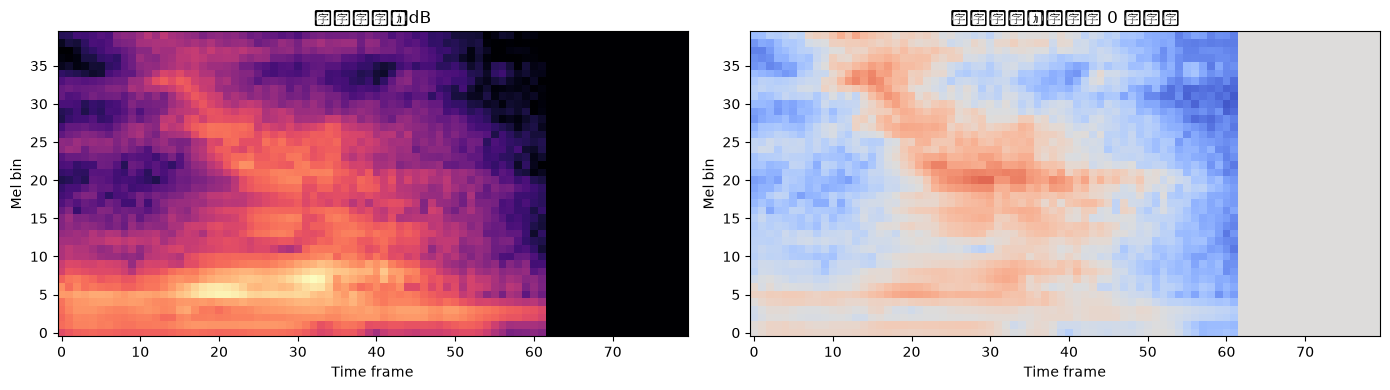

In [5]:
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].imshow(batch[0].T,origin='lower',aspect='auto',vmin=-80,vmax=0,cmap='magma')
axes[0].set_title('归一化前：dB')
axes[1].imshow(normalized[0].T,origin='lower',aspect='auto',cmap='coolwarm',vmin=-3,vmax=3)
axes[1].set_title('归一化后：大致以 0 为中心')
for ax in axes:ax.set_xlabel('Time frame');ax.set_ylabel('Mel bin')
plt.tight_layout();plt.show()

## 4. 转换为 Tensor

模型输入 dtype 通常为 `torch.float32`，分类标签为 `torch.int64`，mask 为 `torch.bool`。

In [6]:
x=torch.from_numpy(normalized).float()
x_lengths=torch.from_numpy(lengths).long()
x_mask=torch.from_numpy(mask).bool()
targets=torch.tensor(labels,dtype=torch.long)
print('x:',x.shape,x.dtype)
print('lengths:',x_lengths.shape,x_lengths.dtype)
print('mask:',x_mask.shape,x_mask.dtype)
print('targets:',targets.shape,targets.dtype)

x: torch.Size([10, 80, 40]) torch.float32
lengths: torch.Size([10]) torch.int64
mask: torch.Size([10, 80]) torch.bool
targets: torch.Size([10]) torch.int64


## 5. `nn.Linear`：逐帧改变特征维度

`nn.Linear(40,64)` 对最后一个维度运算。它不会混合不同时间帧：每个 `(40,)` 帧独立映射成 `(64,)`。

$$y=xW^T+b$$

输入 `(B,T,40)`，输出 `(B,T,64)`。B 和 T 不变。

In [7]:
projection=nn.Linear(40,64)
projected=projection(x)
print('input:',x.shape)
print('output:',projected.shape)
print('weight:',projection.weight.shape)
print('bias:',projection.bias.shape)
print('参数总数:',sum(p.numel() for p in projection.parameters()))

input:

 torch.Size([10, 80, 40])
output: torch.Size([10, 80, 64])
weight: torch.Size([64, 40])
bias: torch.Size([64])
参数总数: 2624


参数数量：$64\times40+64=2624$。同一组权重会用于所有 batch 样本的所有时间帧。

In [8]:
# 验证：手算第 0 条音频第 0 帧，与 Linear 输出一致
manual_one_frame=x[0,0]@projection.weight.T+projection.bias
print('结果一致:',torch.allclose(manual_one_frame,projected[0,0]))

结果一致: True


### 练习 2

1. `Linear(40,64)` 改变 B、T、F 中哪个维度？
2. 权重矩阵为什么是 `(64,40)`？
3. 如果 hidden dim 改成 128，输出 shape 是什么？参数数量是多少？

## 6. ReLU：加入非线性

如果只连续使用 Linear，多层仍可合并成一个线性变换。ReLU 使用 $max(0,x)$：负数变 0，正数保留，使模型能表示非线性关系。ReLU 不改变 shape。

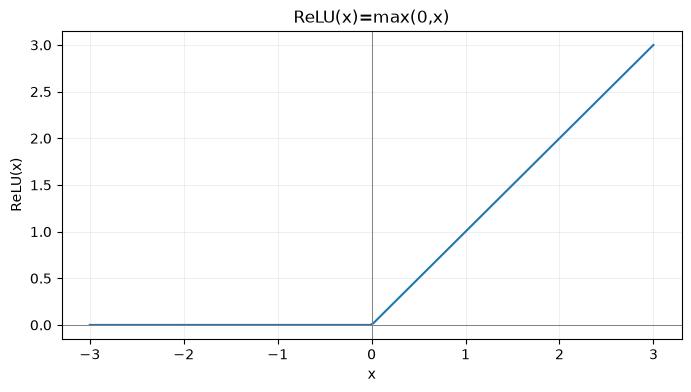

In [9]:
values=torch.linspace(-3,3,200)
relu_values=torch.relu(values)
plt.figure(figsize=(8,4));plt.plot(values.numpy(),relu_values.numpy())
plt.axhline(0,color='gray',linewidth=0.7);plt.axvline(0,color='gray',linewidth=0.7)
plt.xlabel('x');plt.ylabel('ReLU(x)');plt.title('ReLU(x)=max(0,x)');plt.grid(alpha=0.2);plt.show()

## 7. LayerNorm：归一化每个时间帧的隐藏维

`LayerNorm(64)` 对最后的 64 个隐藏值归一化。每个 batch、每个时间帧分别计算，不会把不同长度样本混在一起。

In [10]:
activated=torch.relu(projected)
layer_norm=nn.LayerNorm(64)
normalized_hidden=layer_norm(activated)
print('shape:',normalized_hidden.shape)
print('第 0 帧归一化前 mean/std:',float(activated[0,0].mean()),float(activated[0,0].std(correction=0)))
print('第 0 帧归一化后 mean/std:',float(normalized_hidden[0,0].mean()),float(normalized_hidden[0,0].std(correction=0)))

shape: torch.Size([10, 80, 64])
第 0 帧归一化前 mean/std: 0.2553301751613617 0.3924332857131958
第 0 帧归一化后 mean/std: 3.166496753692627e-08 0.9999675154685974


C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\1118524793.py:5: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print('第 0 帧归一化前 mean/std:',float(activated[0,0].mean()),float(activated[0,0].std(correction=0)))


## 8. 实现最小声学编码器

`nn.Module` 用于组织可训练层。`forward` 定义数据流。最后使用 mask 将 padding 位置隐藏表示清零。

In [11]:
class AcousticFrameEncoder(nn.Module):
    def __init__(self,input_dim=40,hidden_dim=64):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(input_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

    def forward(self,features,valid_mask):
        hidden=self.network(features)
        hidden=hidden*valid_mask.unsqueeze(-1)
        return hidden

encoder=AcousticFrameEncoder(40,64)
hidden=encoder(x,x_mask)
print(encoder)
print('input:',x.shape)
print('hidden:',hidden.shape)
print('参数总数:',sum(p.numel() for p in encoder.parameters()))

AcousticFrameEncoder(
  (network): Sequential(
    (0): Linear(in_features=40, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
)
input: torch.Size([10, 80, 40])
hidden: torch.Size([10, 80, 64])
参数总数: 6912


### 为什么 `unsqueeze(-1)`？

mask 原来是 `(B,T)`，hidden 是 `(B,T,D)`。`unsqueeze(-1)` 将 mask 变成 `(B,T,1)`，广播到所有 D 个隐藏维。

In [12]:
print('mask:',x_mask.shape)
print('unsqueezed:',x_mask.unsqueeze(-1).shape)
print('padding hidden 全为 0:',torch.all(hidden[~x_mask]==0).item())

mask: torch.Size([10, 80])
unsqueezed: torch.Size([10, 80, 1])
padding hidden 全为 0: True


## 9. 如果不应用 mask，padding 会产生非零隐藏值

即使输入 padding 是 0，Linear 的 bias 也可能让输出非零；后续 LayerNorm 等层还会继续变化。因此不能认为输入补零后模型会自动忽略 padding。

应用 mask 前 padding 平均绝对值: 0.8501940965652466
应用 mask 后 padding 平均绝对值: 0.0


C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\3357115022.py:13: UserWarning: Glyph 27809 (\N{CJK UNIFIED IDEOGRAPH-6CA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\3357115022.py:13: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\3357115022.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\3357115022.py:13: UserWarning: Glyph 20173 (\N{CJK UNIFIED IDEOGRAPH-4ECD}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\3357115022.py:13: UserWarning: Glyph 38544 (\N{CJK UNIFIED IDEOGRAPH-9690}) missing from font(s) DejaVu Sans.
  plt.tight_layout();plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_9980\3357115022.py:13: U

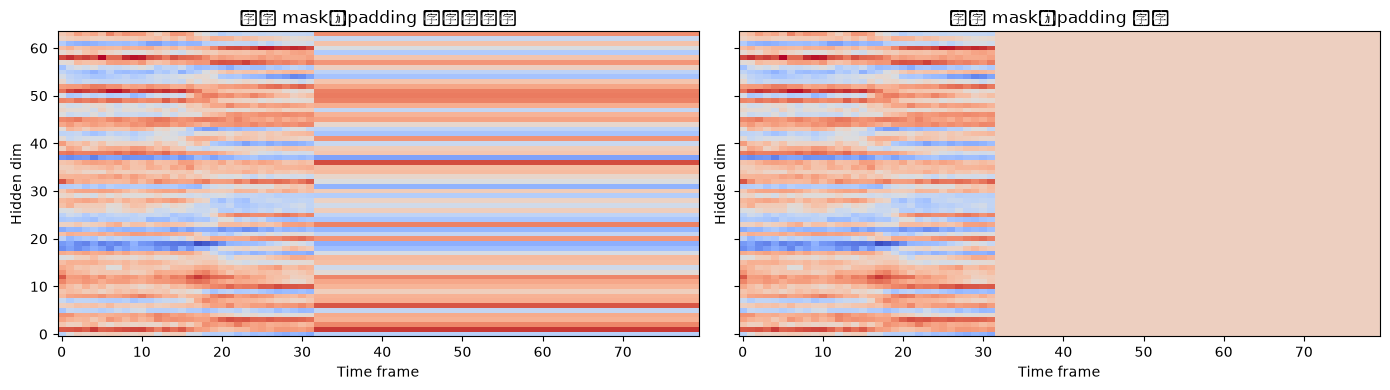

In [13]:
with torch.no_grad():
    unmasked_hidden=encoder.network(x)
pad_energy_before=unmasked_hidden[~x_mask].abs().mean()
pad_energy_after=hidden[~x_mask].abs().mean()
print('应用 mask 前 padding 平均绝对值:',float(pad_energy_before))
print('应用 mask 后 padding 平均绝对值:',float(pad_energy_after))
fig,axes=plt.subplots(1,2,figsize=(14,4),sharey=True)
axes[0].imshow(unmasked_hidden[8].detach().T,origin='lower',aspect='auto',cmap='coolwarm')
axes[0].set_title('没有 mask：padding 仍有隐藏值')
axes[1].imshow(hidden[8].detach().T,origin='lower',aspect='auto',cmap='coolwarm')
axes[1].set_title('使用 mask：padding 清零')
for ax in axes:ax.set_xlabel('Time frame');ax.set_ylabel('Hidden dim')
plt.tight_layout();plt.show()

## 10. 交互查看某个时间帧

拖动帧索引，对比 40 维输入特征和 64 维隐藏表示。隐藏维不再直接对应 Mel 频带，而是模型学习出的组合特征。

In [14]:
def inspect_frame(frame_index=0):
    frame_index=min(frame_index,int(x_lengths[0])-1)
    fig,axes=plt.subplots(1,2,figsize=(13,3.5))
    axes[0].bar(np.arange(40),x[0,frame_index].numpy())
    axes[0].set(title=f'Input frame {frame_index}',xlabel='Mel bin',ylabel='Normalized value')
    axes[1].bar(np.arange(64),hidden[0,frame_index].detach().numpy())
    axes[1].set(title='Encoded hidden vector',xlabel='Hidden dim',ylabel='Value')
    for ax in axes:ax.grid(axis='y',alpha=0.2)
    plt.tight_layout();plt.show()
widgets.interact(inspect_frame,frame_index=widgets.IntSlider(value=0,min=0,max=int(x_lengths[0])-1,step=1,description='Frame'))

interactive(children=(IntSlider(value=0, description='Frame', max=61), Output()), _dom_classes=('widget-intera…

<function __main__.inspect_frame(frame_index=0)>

## 11. Masked mean pooling：从时间序列得到一句话向量

当前 hidden 是 `(B,T,D)`。若做数字分类，可以把有效时间帧求平均，得到 `(B,D)`。这会丢失详细时间顺序，但适合演示 utterance-level 分类。

In [15]:
def masked_mean(hidden,mask):
    weights=mask.unsqueeze(-1).to(hidden.dtype)
    return (hidden*weights).sum(dim=1)/weights.sum(dim=1).clamp_min(1)

utterance_vectors=masked_mean(hidden,x_mask)
print('hidden:',hidden.shape)
print('utterance vectors:',utterance_vectors.shape)

hidden: torch.Size([10, 80, 64])
utterance vectors: torch.Size([10, 64])


## 12. 添加分类头并计算 loss

分类头将 64 维句向量映射到 10 个数字类别。当前模型尚未训练，logits 和预测没有实际识别能力。CrossEntropyLoss 比较 logits 与正确标签。

In [16]:
classifier=nn.Linear(64,10)
logits=classifier(utterance_vectors)
loss_fn=nn.CrossEntropyLoss()
loss=loss_fn(logits,targets)
print('logits:',logits.shape)
print('targets:',targets.shape)
print('initial loss:',float(loss))
print('random predictions:',logits.argmax(dim=-1).tolist())

logits: torch.Size([10, 10])
targets: torch.Size([10])
initial loss: 2.3406670093536377
random predictions: [4, 4, 1, 3, 4, 1, 4, 4, 9, 3]


## 13. 自动求导：一次训练步骤

`loss.backward()` 计算每个参数的梯度，`optimizer.step()` 根据梯度更新参数。这里仅演示一步，不代表模型已经学会识别。

In [17]:
model=nn.Sequential()  # 这里只用列表统一交给 optimizer
parameters=list(encoder.parameters())+list(classifier.parameters())
optimizer=torch.optim.Adam(parameters,lr=1e-3)
optimizer.zero_grad()
hidden=encoder(x,x_mask)
logits=classifier(masked_mean(hidden,x_mask))
loss_before=loss_fn(logits,targets)
loss_before.backward()
first_grad=next(encoder.parameters()).grad
print('loss:',float(loss_before))
print('第一层梯度 shape:',first_grad.shape)
print('梯度平均绝对值:',float(first_grad.abs().mean()))
optimizer.step()
with torch.no_grad():
    loss_after=loss_fn(classifier(masked_mean(encoder(x,x_mask),x_mask)),targets)
print('更新一次后的 loss:',float(loss_after))

loss: 2.3406670093536377
第一层梯度 shape: torch.Size([64, 40])
梯度平均绝对值: 0.011005492880940437
更新一次后的 loss: 2.242372989654541


### 重要提醒

这 10 条音频同时用于计算和更新，只是演示训练机制。真正评估模型必须划分 train/validation/test，不能用训练样本上的低 loss 证明模型能泛化。

## 本课测试

1. Tensor 相比 NumPy array 多了哪些机器学习能力？
2. ASR 特征 tensor `(B,T,F)` 分别表示什么？
3. `Linear(40,64)` 改变哪个维度？
4. Linear 的 bias 为什么会使零 padding 产生非零输出？
5. ReLU 的公式是什么？它改变 shape 吗？
6. `LayerNorm(64)` 对哪个维度归一化？
7. `mask.unsqueeze(-1)` 的 shape 是什么？为什么需要它？
8. 编码器输出 `(B,T,D)` 中 D 是什么？
9. hidden dim 是否还能直接解释为某个 Mel 频带？
10. masked mean 为什么要除以有效帧数，而不是 T？
11. 分类 logits `(B,10)` 表示什么？
12. `loss.backward()` 做什么？
13. `optimizer.step()` 做什么？
14. 为什么一条样本既训练又测试是不可靠的？
15. 当前逐帧 MLP 能否利用前后帧上下文？为什么？

参考答案：1 自动求导、网络层、优化器、设备管理；2 batch/时间/特征；3 F；4 bias 本身可能非零；5 max(0,x)，不改变；6 最后的 hidden 维；7 `(B,T,1)`，用于广播；8 学习到的隐藏特征维；9 不能；10 排除 padding；11 每条音频对 10 类的未归一化分数；12 计算梯度；13 更新参数；14 无法测量泛化；15 不能，每一帧独立经过相同 MLP。

## 小结

`Log-Mel (B,T,40) → Tensor → Linear/ReLU/LayerNorm → hidden (B,T,64) → masked pooling → logits (B,10) → loss`

这个编码器仍然看不到前后文。下一课学习时间上下文：先用一维卷积理解局部上下文和时间下采样，再为 Transformer/Conformer 做准备。

<!-- course-upgrade-v2 -->
## 强化练习：第 8 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `tensor shape`、`线性层`、`最小编码器`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**交换 T 与 F 后仍能运行某些操作**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**为每层打印和断言 shape**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**说明 encoder 输出为何需要 CTC head**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：tensor shape、线性层、最小编码器。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 tensor shape、线性层、最小编码器。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
